In [22]:
import os
import glob
import pandas as pd


# ==========================================
# SETTINGS
# ==========================================
FOLDER_PATH = "Data/Sessions/SessionGames/"


file_pattern = os.path.join(FOLDER_PATH, "*.csv")
session_files = glob.glob(file_pattern)

temp = {}
for i in range(1, 16):
    temp[i] = []


print(temp)

final_df = pd.DataFrame(temp)


final_df.head()

for file in session_files:
    try:
        df = pd.read_csv(file)
        for i in range(1, 16):
            wins = df.loc[df['game_in_session'] == i, 'win']
            temp[i].extend(wins.to_list())
        
    except Exception as e:
        print(f"Error processing {file}: {e}")
final_df = pd.DataFrame({key: pd.Series(value) for key, value in temp.items()})
output_path = "Data/Sessions/winrate_summary.csv"
final_df.to_csv(output_path, index=False)
print(f"Saved final dataframe to {output_path}")
final_df.head()

{1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: [], 10: [], 11: [], 12: [], 13: [], 14: [], 15: []}
Saved final dataframe to Data/Sessions/winrate_summary.csv


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,False,True,True,True,False,False,True,True,True,True,True,False,True,True,True
1,True,True,False,True,False,False,True,False,True,True,True,False,True,False,False
2,True,False,True,False,False,True,False,True,False,False,False,True,False,False,False
3,False,True,True,True,False,False,True,False,True,False,False,True,False,True,False
4,True,False,True,True,True,True,False,False,False,True,True,True,False,False,False


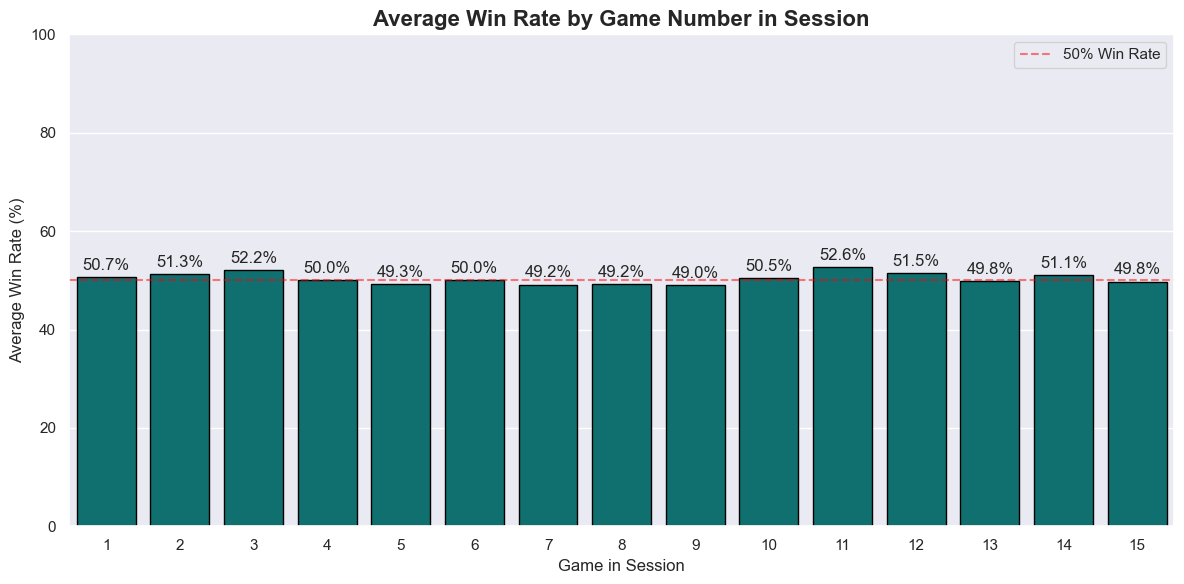

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set visual style
sns.set_theme(style="darkgrid")

# Convert wide-form game-in-session data into long-form for seaborn
plot_data = final_df.melt(var_name='game_in_session', value_name='winrate')
plot_data['game_in_session'] = plot_data['game_in_session'].astype(int)
plot_data['winrate'] = plot_data['winrate'] * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_data,
    x='game_in_session',
    y='winrate',
    color='teal',
    edgecolor='black',
    errorbar=None
)

plt.title('Average Win Rate by Game Number in Session', fontsize=16, fontweight='bold')
plt.xlabel('Game in Session', fontsize=12)
plt.ylabel('Average Win Rate (%)', fontsize=12)
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% Win Rate')
plt.ylim(0, 100)
plt.legend()

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()